**Project Git Hub Link:**


**Project Summary**



*   This project focuses on building a machine learning model to predict the monthly closing stock price of YES Bank using historical stock market data.
*   YES Bank experienced significant financial events, including major changes in stock price trends. The objective of this project is to analyze historical stock price patterns and build a predictive model that can estimate future closing prices.
*   The project follows a complete machine learning workflow including data understanding, exploratory data analysis, data preprocessing, feature engineering, model building, evaluation, and model interpretation.
*   Different regression algorithms like XGB,LR and randomforest are compared to identify the best performing model. The final model helps stakeholders understand important factors affecting stock price movement and supports better data-driven financial decisions.


**Problem Statement**
The objective of this project is to predict the closing price of YES Bank stock using historical stock market information such as opening price, highest price, lowest price, and other derived features.

Stock price prediction is challenging because financial markets are influenced by multiple factors. Machine learning techniques can help identify hidden relationships between historical features and future price movements.

The goal is to develop a regression model that minimizes prediction error and provides reliable closing price estimates.


**Business Context**

Stock price prediction plays an important role for investors, financial analysts, and business stakeholders.

Accurate forecasting helps:
1. Understand stock movement patterns.
2. Support investment decision-making.
3. Identify important market indicators.
4. Manage financial risk.

For YES Bank, analyzing historical price behavior is important because the bank experienced significant market fluctuations. Predictive analytics can provide insights into stock trends and important price-driving factors.

**Data Understanding**

The dataset contains historical monthly stock information of YES Bank.

The important features include:

Date:
Represents the month and year of stock records.

Open:
Opening price of the stock during the month.

High:
Highest stock price reached during the month.

Low:
Lowest stock price reached during the month.

Close:
Final closing price of the stock for the month.

The target variable for this project is Close price because the objective is to predict the final stock value.

**Dataset Loading and Cleanup**

In [ ]:
import pandas as pd
import numpy as np
import os


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

#os.listdir('/content/drive/MyDrive')

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/data_YesBank_StockPrices.csv")

In [ ]:
df

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41
...,...,...,...,...,...
180,Jul-20,25.60,28.30,11.10,11.95
181,Aug-20,12.00,17.16,11.85,14.37
182,Sep-20,14.30,15.34,12.75,13.15
183,Oct-20,13.30,14.01,12.11,12.42


In [ ]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


In [ ]:
from datetime import datetime

In [ ]:
df['Date'].head(5)

,Date
0,Jul-05
1,Aug-05
2,Sep-05
3,Oct-05
4,Nov-05


In [ ]:
df["Date"] = pd.to_datetime(df["Date"], format="%b-%y", errors="raise")

**Exploratory Data Analysis (EDA)**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    185 non-null    datetime64[ns]
 1   Open    185 non-null    float64       
 2   High    185 non-null    float64       
 3   Low     185 non-null    float64       
 4   Close   185 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 7.4 KB


In [ ]:
df.describe()

,Date,Open,High,Low,Close
count,185,185.000000,185.000000,185.000000,185.000000
mean,2013-03-01 19:04:12.972973056,105.541405,116.104324,94.947838,105.204703
min,2005-07-01 00:00:00,10.000000,11.240000,5.550000,9.980000
25%,2009-05-01 00:00:00,33.800000,36.140000,28.510000,33.450000
50%,2013-03-01 00:00:00,62.980000,72.550000,58.000000,62.540000
75%,2017-01-01 00:00:00,153.000000,169.190000,138.350000,153.300000
max,2020-11-01 00:00:00,369.950000,404.000000,345.500000,367.900000
std,NaN,98.879850,106.333497,91.219415,98.583153


In [ ]:
#"Since the dataset contains only 185 monthly observations, deep learning models such as LSTMs are likely to overfit.
#Therefore, I would first explore statistical time-series methods and tree-based regression models."

**Feature Engineering**

In [ ]:
#Variable Creation
df["Close_lag_1_month"] = df["Close"].shift(1)
df["Close_lag_3_month"] = df["Close"].shift(3)
df["Close_lag_6_month"] = df["Close"].shift(6)

In [ ]:
# Rolling Means
df['rolling_mean_3'] = df['Close'].shift(1).rolling(window=3).mean()

df['rolling_mean_6'] = df['Close'].shift(1).rolling(window=6).mean()

# Rolling Standard Deviations
df['rolling_std_3'] = df['Close'].shift(1).rolling(window=3).std()

df['rolling_std_6'] = df['Close'].shift(1).rolling(window=6).std()

In [ ]:
# Price Range
df['price_range'] = df['High'] - df['Low']

# Open-Close Difference
df['open_close_diff'] = df['Close'] - df['Open']

# Percentage Return
df['return_pct'] = ((df['Close'] - df['Open']) / df['Open']) * 100

# Volatility
df['volatility_pct'] = ((df['High'] - df['Low']) / df['Open']) * 100

In [ ]:
df['Close_lag1'] = df['Close'].shift(1)
df['Close_lag3'] = df['Close'].shift(3)
df['Close_lag6'] = df['Close'].shift(6)

df['Open_lag1'] = df['Open'].shift(1)
df['High_lag1'] = df['High'].shift(1)
df['Low_lag1'] = df['Low'].shift(1)

In [ ]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Close_lag_1_month,1
Close_lag_3_month,3
Close_lag_6_month,6
rolling_mean_3,3
rolling_mean_6,6


In [ ]:
df = df.dropna().reset_index(drop = True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(179, 22)

In [ ]:
#pip install matplotlib

In [ ]:
#pip install seaborn

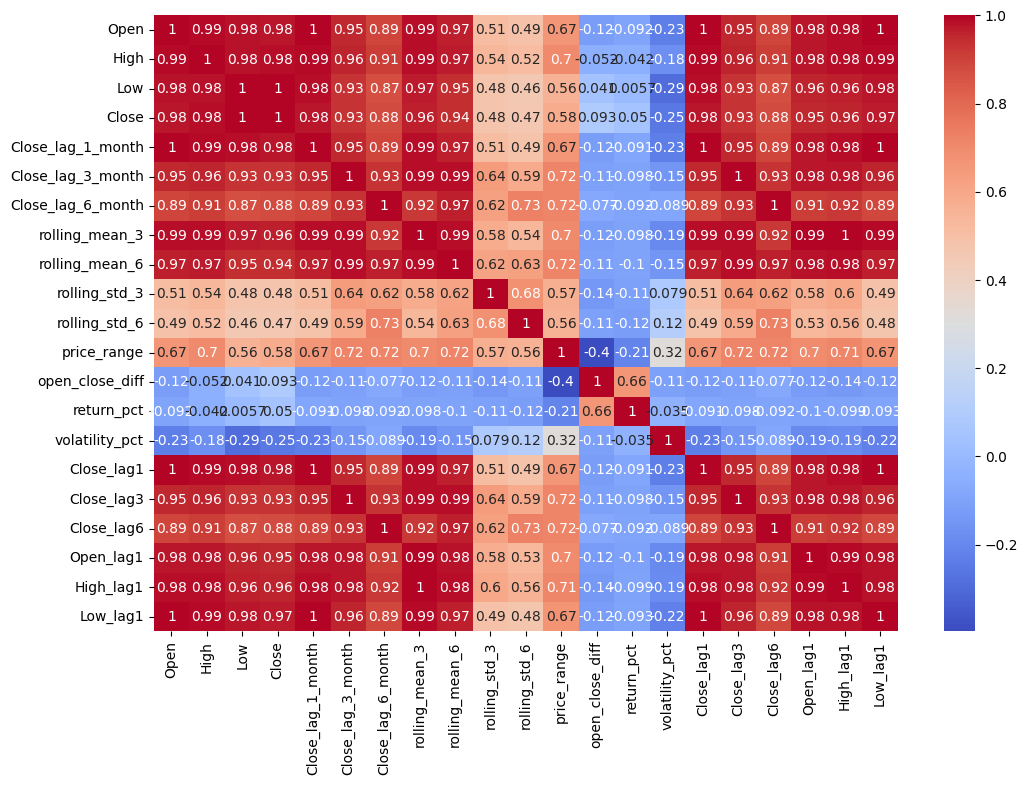

In [ ]:
import seaborn as sns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
#"The stock exhibits a structural break after 2018 due to significant business events. This creates a
#challenging forecasting environment because the model must learn both growth and crash periods."

In [ ]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['quarter'] = df['Date'].dt.quarter

**Target Feature understanding**
The target variable for this project is the Close price.

Since this is a regression problem, the distribution of the target variable was analyzed instead of checking class imbalance.

The analysis included:

- Distribution plot of Close price.
- Checking skewness.
- Identifying extreme values.
- Understanding price fluctuations over different periods.

Understanding the target variable helps improve model performance and choose suitable preprocessing techniques.

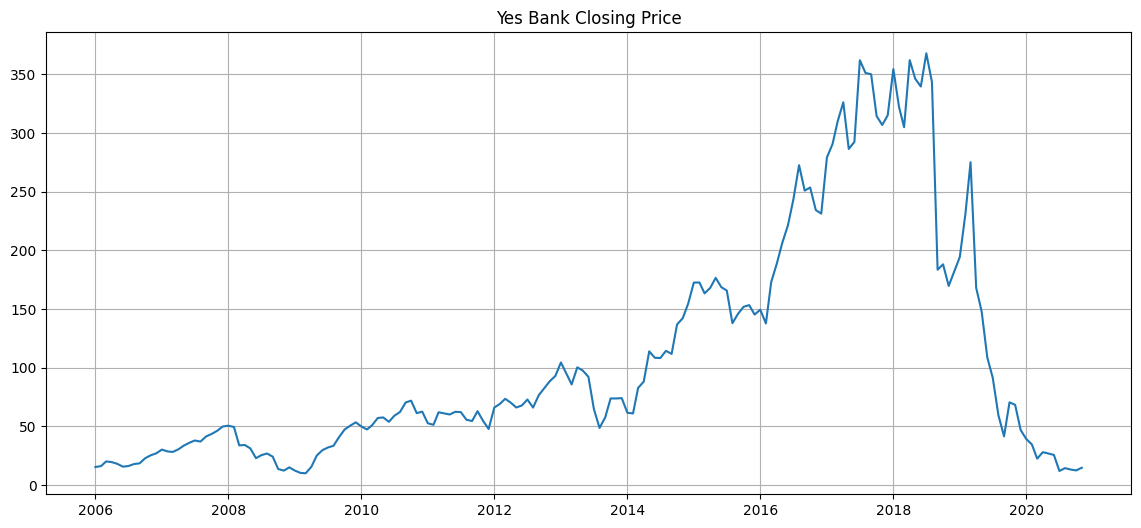

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Close'])
plt.title("Yes Bank Closing Price")
plt.grid(True)
plt.show()

In [ ]:
df['target_close_next_month'] = df['Close'].shift(-1)
df = df.dropna().reset_index(drop=True)

In [ ]:
features = [
    'Close_lag1',
    'Close_lag3',
    'Close_lag6',
    'rolling_mean_3',
    'rolling_mean_6',
    'rolling_std_3',
    'rolling_std_6',
    'price_range',
    'return_pct',
    'volatility_pct',
    'month',
    'quarter'
]

target = 'target_close_next_month'

**Data Preparation for Training**

In [ ]:
split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

X_train = train[features]
X_test = test[features]

y_train = train[target]
y_test = test[target]

In [ ]:
#pip install scikit-learn

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [ ]:
actual = y_test
predicted = pred_xgb

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, pred_lr)

rmse = np.sqrt(
    mean_squared_error(y_test, pred_lr)
)

r2 = r2_score(y_test, pred_lr)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 46.99180397090735
RMSE: 66.68695956298406
R2  : 0.7261551622509488


In [ ]:
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2_xgb = r2_score(y_test, pred_xgb)

print(f"{mae_lr}, {rmse_lr} ,{r2_lr}")
print(f"{mae_rf}, {rmse_rf}, {r2_rf}")
print(f"{mae_xgb}, {rmse_xgb},{r2_xgb}")

46.99180397090735, 66.68695956298406 ,0.7261551622509488
44.6495627981064, 61.73949321470225, 0.7652806766225427
36.602938139173716, 51.9781472359401,0.8336340999222329


In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [mae_lr, mae_rf, mae_xgb],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'R2': [r2_lr, r2_rf, r2_xgb]
})

print(results)

               Model        MAE       RMSE        R2
0  Linear Regression  46.991804  66.686960  0.726155
1      Random Forest  44.649563  61.739493  0.765281
2            XGBoost  36.602938  51.978147  0.833634


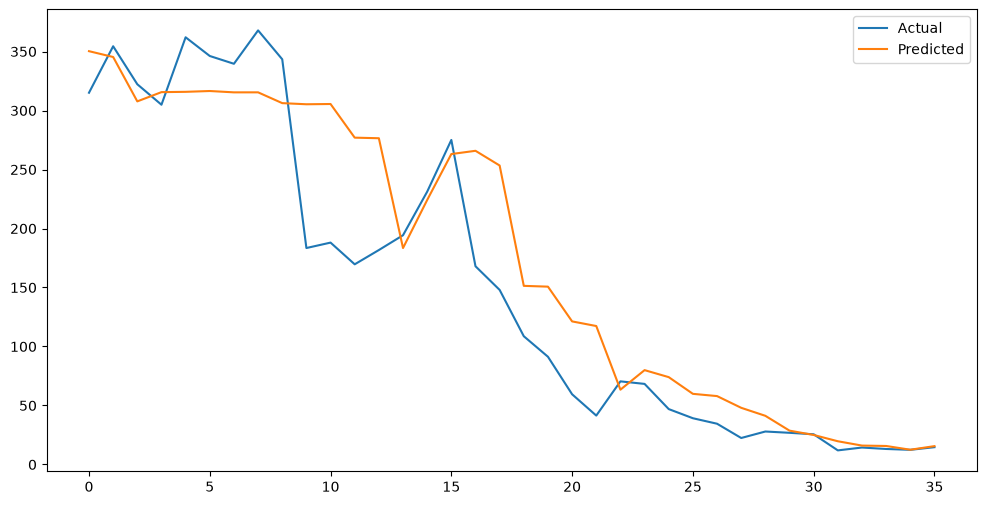

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(actual.values, label='Actual')
plt.plot(predicted, label='Predicted')
plt.legend()
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

print(feature_importance)

           Feature  Importance
3   rolling_mean_3    0.742414
0       Close_lag1    0.186011
4   rolling_mean_6    0.050465
2       Close_lag6    0.014376
5    rolling_std_3    0.002346
7      price_range    0.001030
8       return_pct    0.000978
1       Close_lag3    0.000809
6    rolling_std_6    0.000656
9   volatility_pct    0.000487
10           month    0.000428
11         quarter    0.000000


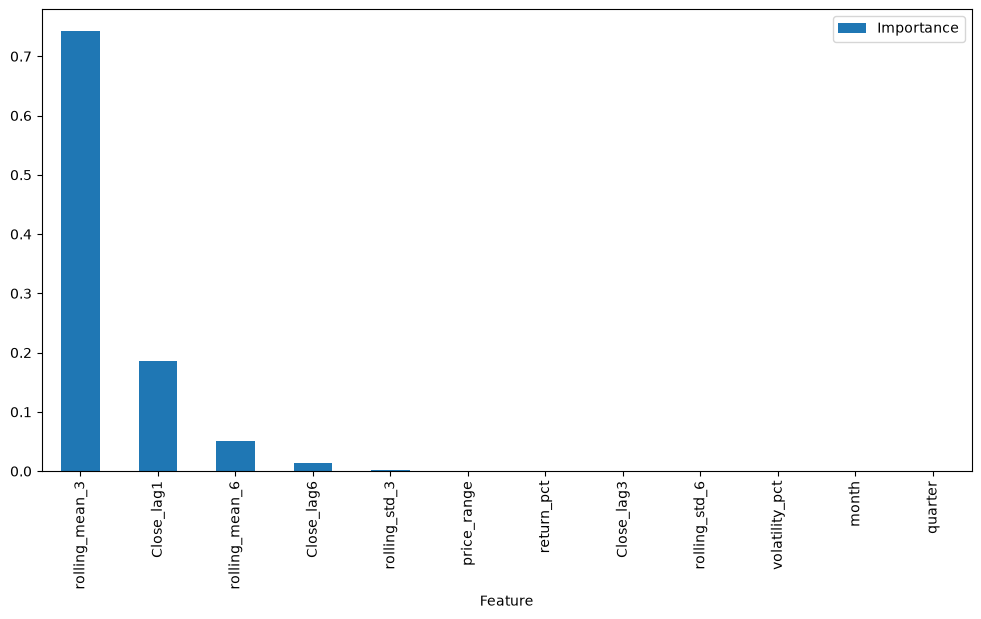

In [ ]:
import matplotlib.pyplot as plt

feature_importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(12,6)
)

plt.show()

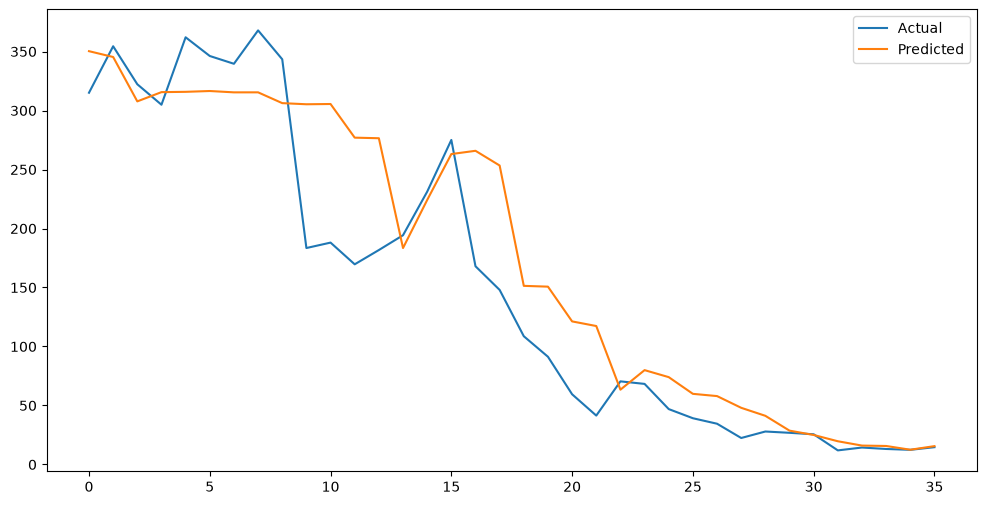

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values,
         label='Actual')

plt.plot(pred_xgb,
         label='Predicted')

plt.legend()

plt.show()

In [ ]:
#MOre Features creation

df['Close_lag12'] = df['Close'].shift(12)

df['rolling_mean_12'] = (
    df['Close']
    .shift(1)
    .rolling(12)
    .mean()
)

df['rolling_std_12'] = (
    df['Close']
    .shift(1)
    .rolling(12)
    .std()
)
df['momentum_3'] = (
    df['Close'].shift(1)
    - df['Close'].shift(3)
)
df['momentum_6'] = (
    df['Close'].shift(1)
    - df['Close'].shift(6)
)

In [ ]:
df_model = df.dropna().reset_index(drop=True)

print(df_model.shape)

(166, 31)


In [ ]:
features1 = [
    'Close_lag1',
    'Close_lag3',
    'Close_lag6',
    'Close_lag12',

    'rolling_mean_3',
    'rolling_mean_6',
    'rolling_mean_12',

    'rolling_std_3',
    'rolling_std_6',
    'rolling_std_12',

    'momentum_3',
    'momentum_6',

    'price_range',
    'return_pct',
    'volatility_pct',

    'month',
    'quarter',
    'year'
]

target = 'target_close_next_month'

In [ ]:
split_idx = int(len(df_model) * 0.8)

train = df_model.iloc[:split_idx]
test = df_model.iloc[split_idx:]

X_train = train[features1]
X_test = test[features1]

y_train = train[target]
y_test = test[target]

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae_lr = mean_absolute_error(y_test, pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, pred_lr)
)

r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)

Linear Regression
MAE : 62.75368726170973
RMSE: 81.8505510133106
R2  : 0.5570681361433713


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, pred_rf)
)

r2_rf = r2_score(y_test, pred_rf)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

Random Forest
MAE : 62.585919152127616
RMSE: 76.62236172587264
R2  : 0.6118453643108768


In [ ]:
from xgboost import XGBRegressor

xgb1 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb1.fit(X_train, y_train)

pred_xgb = xgb1.predict(X_test)

In [ ]:
mae_xgb = mean_absolute_error(y_test, pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, pred_xgb)
)

r2_xgb = r2_score(y_test, pred_xgb)

print("XGBoost")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)

XGBoost
MAE : 56.67261244381175
RMSE: 66.7560067466853
R2  : 0.705371734626067


In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'MAE': [
        mae_lr,
        mae_rf,
        mae_xgb
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],
    'R2': [
        r2_lr,
        r2_rf,
        r2_xgb
    ]
})

results.sort_values(
    by='R2',
    ascending=False
)

,Model,MAE,RMSE,R2
2,XGBoost,56.672612,66.756007,0.705372
1,Random Forest,62.585919,76.622362,0.611845
0,Linear Regression,62.753687,81.850551,0.557068


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb1.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

            Feature  Importance
4    rolling_mean_3    0.374179
0        Close_lag1    0.205085
5    rolling_mean_6    0.170086
17             year    0.159966
2        Close_lag6    0.029551
1        Close_lag3    0.016920
3       Close_lag12    0.016001
9    rolling_std_12    0.010137
6   rolling_mean_12    0.008556
7     rolling_std_3    0.003068
13       return_pct    0.001292
11       momentum_6    0.001285
14   volatility_pct    0.001028
8     rolling_std_6    0.000811
10       momentum_3    0.000688
15            month    0.000595
12      price_range    0.000501
16          quarter    0.000251


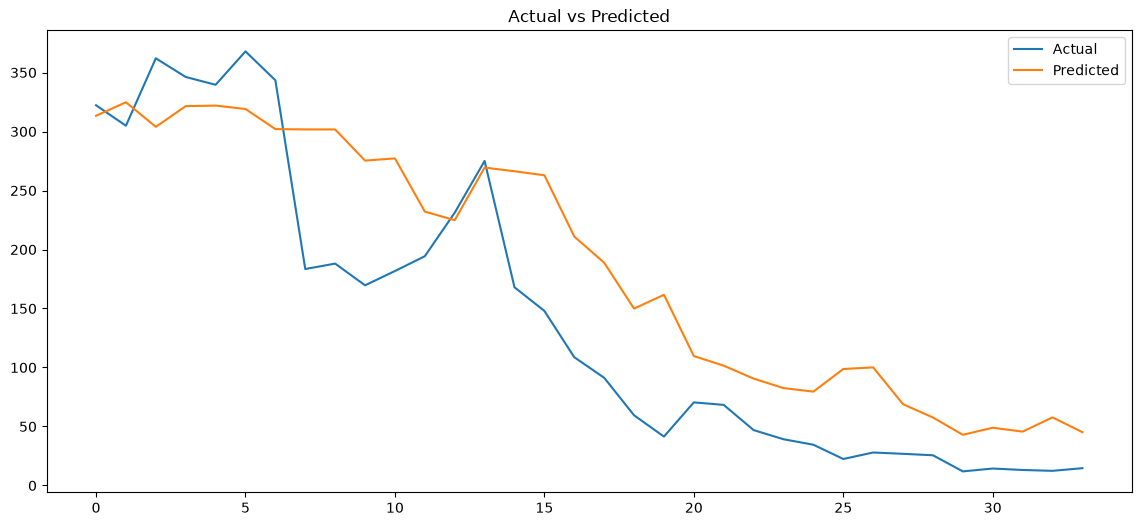

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    pred_xgb,
    label='Predicted'
)

plt.title('Actual vs Predicted')

plt.legend()

plt.show()

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

tscv = TimeSeriesSplit(n_splits=5)

scores = []

for train_idx, test_idx in tscv.split(df_model):

    X_train_cv = df_model.iloc[train_idx][features]
    X_test_cv = df_model.iloc[test_idx][features]

    y_train_cv = df_model.iloc[train_idx][target]
    y_test_cv = df_model.iloc[test_idx][target]

    xgb1.fit(X_train_cv, y_train_cv)

    preds = xgb.predict(X_test_cv)

    scores.append(
        r2_score(
            y_test_cv,
            preds
        )
    )

print("CV R2 Scores:", scores)
print("Average R2:", np.mean(scores))

CV R2 Scores: [0.9633217026272556, 0.989851771791938, 0.9970427207561989, 0.9992563103214397, 0.5232742174811438]
Average R2: 0.8945493445955952


In [ ]:
#Hyper parameter tuning
xgb2 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb2.fit(X_train, y_train)

pred_xgb2 = xgb2.predict(X_test)

In [ ]:
xgb3 = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb3.fit(X_train, y_train)

pred_xgb3 = xgb3.predict(X_test)

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb2.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

            Feature  Importance
4    rolling_mean_3    0.318739
17             year    0.228456
0        Close_lag1    0.214316
5    rolling_mean_6    0.143090
2        Close_lag6    0.030873
9    rolling_std_12    0.024421
1        Close_lag3    0.015483
7     rolling_std_3    0.007469
3       Close_lag12    0.004691
6   rolling_mean_12    0.004180
13       return_pct    0.002295
11       momentum_6    0.001404
10       momentum_3    0.001259
14   volatility_pct    0.000904
8     rolling_std_6    0.000888
16          quarter    0.000678
15            month    0.000428
12      price_range    0.000426


In [ ]:
mae_xgb = mean_absolute_error(y_test, pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, pred_xgb)
)

r2_xgb = r2_score(y_test, pred_xgb)

print("XGBoost")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)

XGBoost
MAE : 56.67261244381175
RMSE: 66.7560067466853
R2  : 0.705371734626067


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb3.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

            Feature  Importance
4    rolling_mean_3    0.525353
0        Close_lag1    0.212305
17             year    0.146772
5    rolling_mean_6    0.065729
2        Close_lag6    0.022358
6   rolling_mean_12    0.005669
9    rolling_std_12    0.005394
3       Close_lag12    0.004077
7     rolling_std_3    0.003897
11       momentum_6    0.002103
13       return_pct    0.001812
1        Close_lag3    0.001736
14   volatility_pct    0.000855
8     rolling_std_6    0.000733
10       momentum_3    0.000422
12      price_range    0.000411
15            month    0.000308
16          quarter    0.000066


In [ ]:
mae_xgb = mean_absolute_error(y_test, pred_xgb3)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, pred_xgb3)
)

r2_xgb = r2_score(y_test, pred_xgb3)

print("XGBoost")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)

XGBoost
MAE : 60.887402114868166
RMSE: 71.27087584308345
R2  : 0.6641712284783143


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

tscv = TimeSeriesSplit(n_splits=5)

scores = []

for train_idx, test_idx in tscv.split(df_model):

    X_train_cv = df.iloc[train_idx][features]
    X_test_cv = df.iloc[test_idx][features]

    y_train_cv = df.iloc[train_idx][target]
    y_test_cv = df.iloc[test_idx][target]

    xgb1.fit(X_train_cv, y_train_cv)

    preds = xgb.predict(X_test_cv)

    scores.append(
        r2_score(
            y_test_cv,
            preds
        )
    )

print("CV R2 Scores:", scores)
print("Average R2:", np.mean(scores))

CV R2 Scores: [0.9970998184403278, 0.98645605852506, 0.9984798062626001, 0.9995867304650065, 0.7565246325082591]
Average R2: 0.9476294092402506


In [ ]:
artifact = {
    "model": xgb,
    "features": features,
    "version": "1.0"
}

In [ ]:
joblib.dump(artifact,"xgb_model.pkl")

['xgb_model.pkl']

In [ ]:
import joblib

artifact = joblib.load("xgb_model.pkl")

model = artifact["model"]

features = artifact["features"]

version = artifact["version"]

print(version)
print(features)

1.0
['Close_lag1', 'Close_lag3', 'Close_lag6', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3', 'rolling_std_6', 'price_range', 'return_pct', 'volatility_pct', 'month', 'quarter']


In [ ]:
import joblib

artifact = joblib.load("xgb_model.pkl")

model = artifact["model"]

features = artifact["features"]

version = artifact["version"]

print(version)
print(features)

1.0
['Close_lag1', 'Close_lag3', 'Close_lag6', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3', 'rolling_std_6', 'price_range', 'return_pct', 'volatility_pct', 'month', 'quarter']


In [ ]:
latest_record = X_test.iloc[[-1]]

latest_record

,Close_lag1,Close_lag3,Close_lag6,Close_lag12,rolling_mean_3,rolling_mean_6,rolling_mean_12,rolling_std_3,rolling_std_6,rolling_std_12,momentum_3,momentum_6,price_range,return_pct,volatility_pct,month,quarter,year
165,13.15,11.95,27.95,70.45,13.156667,19.978333,33.480833,1.210014,7.548564,19.759583,1.2,-14.8,1.9,-6.616541,14.285714,10,4,2020


In [ ]:
prediction = model.predict(latest_record[features])

print(prediction)

[16.199787]


In [ ]:
#pip install shap

In [ ]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test[features])

In [ ]:
features = ['Close_lag1', 'Close_lag3', 'Close_lag6', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3', 'rolling_std_6', 'price_range', 'return_pct', 'volatility_pct', 'month', 'quarter']

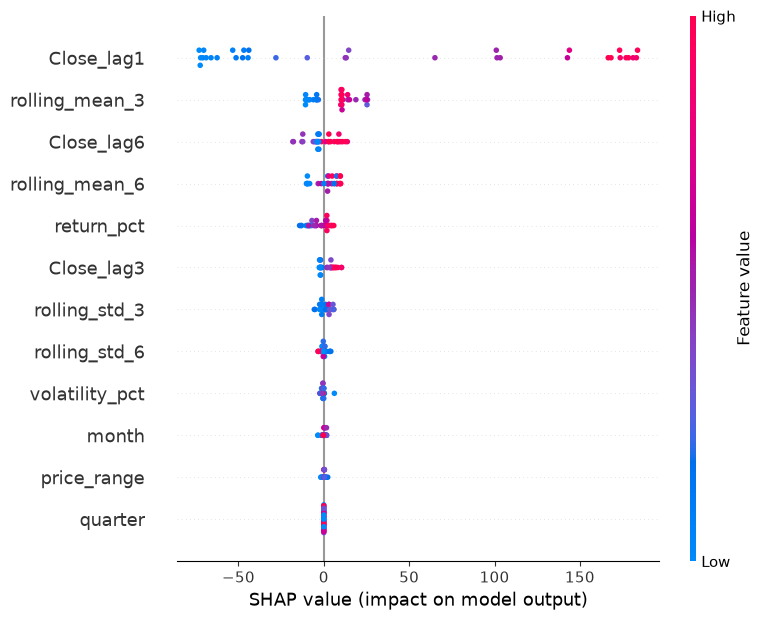

In [ ]:
shap.summary_plot(
    shap_values,
    X_test[features]
)

In [ ]:
import joblib
import pandas as pd

artifact = joblib.load("xgb_model.pkl")

model = artifact["model"]
features = artifact["features"]

def predict(data):

    df = pd.DataFrame([data])

    prediction = model.predict(df)

    return float(prediction[0])

In [ ]:
#pip install fastapi uvicorn

In [ ]:
%%writefile app.py


from fastapi import FastAPI
import pandas as pd
import joblib

app = FastAPI()

artifact = joblib.load("xgb_model.pkl")

model = artifact["model"]
features = artifact["features"]


@app.get("/")
def home():
    return {
        "status": "running",
        "model_version": artifact["version"]
    }


@app.post("/predict")
def predict(data: dict):

    df = pd.DataFrame([data])

    df = df[features]

    prediction = model.predict(df)

    return {
        "prediction": float(prediction[0])
    }

Writing app.py


In [ ]:
#!{sys.executable} -m pip list | findstr uvicorn

**Conclusion:**
Build machine-learning model for predicting the next month's YES BANK closing price. Historical market data was transformed through lag, rolling, return, volatility, and time-based features, followed by training and comparison of multiple machine-learning algorithms. The selected model was saved as a reusable model artifact for inference.

Model explainability was incorporated using feature importance and SHAP to understand the key drivers behind predictions.
